# Electronics Ecommerce Analytics Project

This project examines a large online retail dataset to understand customer behavior for electronics products. The analysis focuses on identifying cart abandonment patterns, customer engagement across browsing and purchase events, and key product segments where conversion can be improved. The objective is to use data-driven insights to support better merchandising, customer experience, and marketing strategies for electronics in a multi-category ecommerce store.

## Project Objective and Context

The business problem is that many online shoppers add electronics items to their carts but do not complete the purchase. Cart abandonment is important because it represents lost revenue and wasted marketing effort. By focusing on electronics products, we reduce dataset size for performance and target a high-value product category with strong conversion potential.

## Import Libraries

We import the key libraries needed for data manipulation and visualization. These libraries are standard for beginner-friendly data analysis in Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure default figure size and style for readability
plt.style.use('default')
sns.set_context('talk')

## Load Dataset

Load the ecommerce behavior dataset from the local project folder. We display the first few rows and the overall shape to confirm the dataset structure and size.

In [2]:
df = pd.read_csv(r'C:\Users\PC\OneDrive\Desktop\Data_Analytics\electronics_full_cleaned.csv')

# Preview the first 5 rows of the dataset
display(df.head())

# Show the size of the dataset
print('Dataset shape:', df.shape)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-02-01 00:00:06 UTC,view,5701024,2053013554415534427,electronics.video.tv,kenwood,120.98,531481119,162a856a-f800-4ca6-a889-cde46fe78972
1,2020-02-01 00:00:06 UTC,view,5100337,2232732103101907535,electronics.clocks,apple,308.85,559727899,9e1fe23c-2d1a-4cfd-b295-344b6736188f
2,2020-02-01 00:00:14 UTC,view,5100343,2232732103101907535,electronics.clocks,apple,330.01,520371403,8ce107a6-3931-4a5d-b1ea-518df50c6e63
3,2020-02-01 00:00:14 UTC,view,5100268,2232732103101907535,electronics.clocks,wonlex,24.17,589176085,83d2a7ab-4e85-4ba0-85af-aa76779b538c
4,2020-02-01 00:00:16 UTC,view,1307056,2053013554658804075,electronics.audio.headphone,apple,1253.31,521752260,518ce4e5-5959-496e-972b-5237cd4ac4c1


Dataset shape: (6093292, 9)


## Dataset Understanding

We examine the dataset structure, summary statistics, column names, and missing values. This helps us understand data quality and plan cleaning steps.

In [3]:
# Display information about columns, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6093292 entries, 0 to 6093291
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     object 
 1   event_type     object 
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  object 
 5   brand          object 
 6   price          float64
 7   user_id        int64  
 8   user_session   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 418.4+ MB


The dataset information shows the available fields and highlights any columns with missing values or unexpected data types. This is the first step toward data cleaning.

In [4]:
# Display summary statistics for numeric columns
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
event_time,6093292,1956196,2020-02-16 04:55:03 UTC,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_type,6093292,3,view,5754842,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_id,6093292.0,NaN,NaN,NaN,30082064.067724,38198318.670454,1000365.0,5100601.0,8801091.0,26027612.0,100144261.0
category_id,6093292.0,NaN,NaN,NaN,2138842278379358976.0,89739964799139008.0,2053013552570040576.0,2053013554658803968.0,2053013560530830080.0,2232732082390434048.0,2232732134987006208.0
category_code,6093292,14,electronics.clocks,2191105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
brand,6093292,807,Unknown,977282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,6093292.0,NaN,NaN,NaN,341.621131,438.972786,0.81,64.33,181.73,428.72,2574.07
user_id,6093292.0,NaN,NaN,NaN,561997538.039861,38152072.059101,29990697.0,522125549.0,562109564.0,598816232.0,622090236.0
user_session,6093291,1720000,1bf74f86-3c3b-4b57-aa9e-822d12530ebc,682,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Summary statistics provide a sense of the numeric distributions and the count of non-null values for each column. This can reveal outliers or unexpected missing entries in numeric fields.

In [5]:
# Display the column names to understand available variables
print('Columns in dataset:')
print(df.columns.tolist())

Columns in dataset:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


Listing the column names helps us identify the relevant fields for electronics filtering, time analysis, pricing, and event classification.

In [6]:
# Check for missing values across columns
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary[missing_summary > 0]

user_session    1
dtype: int64

Identifying missing values allows us to handle incomplete records in a consistent way before further analysis.

## Filter Electronics Data

We focus on electronics products to reduce dataset volume and concentrate on a high-value category. This step isolates records related to electronics behavior.

In [7]:
# Filter rows where category_code contains 'electronics'
electronics_df = df[df['category_code'].astype(str).str.contains('electronics', case=False, na=False)].copy()

# Confirm the filtered dataset size
print('Electronics dataset shape:', electronics_df.shape)

Electronics dataset shape: (6093292, 9)


The filtered electronics dataset contains only the records relevant to our focused product category. This improves analysis speed and relevance.

## Handle Missing Values

We identify missing values in key fields and fill them with meaningful categories to avoid losing records during analysis.

In [8]:
# Check missing values in the filtered electronics dataset
missing_electronics = electronics_df[['brand', 'category_code']].isnull().sum()
print(missing_electronics)

# Fill missing brand and category values with 'Unknown'
electronics_df['brand'] = electronics_df['brand'].fillna('Unknown')
electronics_df['category_code'] = electronics_df['category_code'].fillna('Unknown')

# Confirm the replacements were applied
electronics_df[['brand', 'category_code']].isnull().sum()

brand            0
category_code    0
dtype: int64


brand            0
category_code    0
dtype: int64

Filling missing values for brand and category ensures that records remain usable for grouping and aggregation. This is important because dropping records can bias the analysis and reduce statistical power.

## Remove Duplicates

Duplicate rows can distort counts and distribution analysis. We quantify the duplicate rows and then remove them.

In [9]:
# Count duplicate rows before removal
duplicates_before = electronics_df.duplicated().sum()
print('Duplicates before removal:', duplicates_before)

# Remove duplicates and count again
electronics_df = electronics_df.drop_duplicates().copy()
duplicates_after = electronics_df.duplicated().sum()
print('Duplicates after removal:', duplicates_after)
print('Shape after deduplication:', electronics_df.shape)

Duplicates before removal: 67696
Duplicates after removal: 0
Shape after deduplication: (6025596, 9)


Removing duplicate rows ensures that counts of views, carts, and purchases reflect unique logged events rather than repeated records.

## Convert Data Types

Convert the event time to a datetime object and create new time-based columns for hourly and weekly pattern analysis.

In [10]:
# Convert the event_time column to datetime
electronics_df['event_time'] = pd.to_datetime(electronics_df['event_time'], errors='coerce')

# Extract useful time features
electronics_df['hour'] = electronics_df['event_time'].dt.hour
electronics_df['day_name'] = electronics_df['event_time'].dt.day_name()
electronics_df['month'] = electronics_df['event_time'].dt.month_name()

# Confirm new columns
electronics_df[['event_time', 'hour', 'day_name', 'month']].head()

,event_time,hour,day_name,month
0,2020-02-01 00:00:06+00:00,0,Saturday,February
1,2020-02-01 00:00:06+00:00,0,Saturday,February
2,2020-02-01 00:00:14+00:00,0,Saturday,February
3,2020-02-01 00:00:14+00:00,0,Saturday,February
4,2020-02-01 00:00:16+00:00,0,Saturday,February


Adding time-based features enables the analysis of peak activity hours, day preferences, and monthly trends for electronics shopping behavior.

## Feature Engineering

Create a categorical price range variable to compare customer behavior across different electronics price segments.

In [11]:
# Create a price_range column with defined bins
price_bins = [0, 100, 500, 1000, np.inf]
price_labels = ['0-100', '100-500', '500-1000', '1000+']
electronics_df['price_range'] = pd.cut(electronics_df['price'].fillna(0), bins=price_bins, labels=price_labels, right=False)

# Confirm the distribution of price ranges
electronics_df['price_range'].value_counts().sort_index()

price_range
0-100       2110461
100-500     2655727
500-1000     813686
1000+        445722
Name: count, dtype: int64

The price range categories allow us to compare different segments of electronics products, helping to identify where most views and purchases occur.

## Exploratory Data Analysis (EDA)

We now explore key patterns in electronics behavior, including browsing, purchase activity, event types, and price dynamics.

In [13]:
# Most viewed brands in electronics
view_counts = electronics_df[electronics_df['event_type'] == 'view'].groupby('brand').size().sort_values(ascending=False).head(10)
print('Top 10 most viewed brands:')
print(view_counts)

# Most purchased brands in electronics
purchase_counts = electronics_df[electronics_df['event_type'] == 'purchase'].groupby('brand').size().sort_values(ascending=False).head(10)
print('\nTop 10 most purchased brands:')
print(purchase_counts)

# Distribution of event types
event_distribution = electronics_df['event_type'].value_counts()
print('\nEvent type distribution:')
print(event_distribution)

# Shopping activity by hour
hourly_activity = electronics_df['hour'].value_counts().sort_index()
print('\nActivity by hour:')
print(hourly_activity)

# Top electronics categories
top_categories = electronics_df['category_code'].value_counts().head(10)
print('\nTop electronics categories:')
print(top_categories)

# Average price by brand for the top 10 brands by occurrence
top_brands = electronics_df['brand'].value_counts().head(10).index
average_price_by_brand = electronics_df[electronics_df['brand'].isin(top_brands)].groupby('brand')['price'].mean().sort_values(ascending=False)
print('\nAverage price by brand (top 10 brands):')
print(average_price_by_brand)

Top 10 most viewed brands:
brand
Unknown    938687
apple      445468
casio      410131
acer       376514
lenovo     356902
asus       258512
samsung    229762
hp         180689
pioneer    152341
nokia      145480
dtype: int64

Top 10 most purchased brands:
brand
apple      16740
acer        9295
Unknown     7963
lenovo      5680
casio       4827
samsung     3903
asus        2908
nokia       2846
hp          2487
pioneer     1675
dtype: int64

Event type distribution:
event_type
view        5719757
cart         222489
purchase      83350
Name: count, dtype: int64

Activity by hour:
hour
0      40156
1      64877
2     117579
3     188245
4     250015
5     289773
6     319416
7     334492
8     346942
9     347931
10    340544
11    327365
12    314615
13    328180
14    361763
15    401702
16    422205
17    400794
18    324409
19    219396
20    130576
21     73624
22     46523
23     34474
Name: count, dtype: int64

Top electronics categories:
category_code
electronics.clocks        

This exploratory analysis identifies the brands and categories with the highest electronic shopping activity, as well as the distribution of event types and hourly demand.

## Visualizations

Visual charts help communicate the key findings from the electronics dataset. The plots below show the most important patterns in the data.

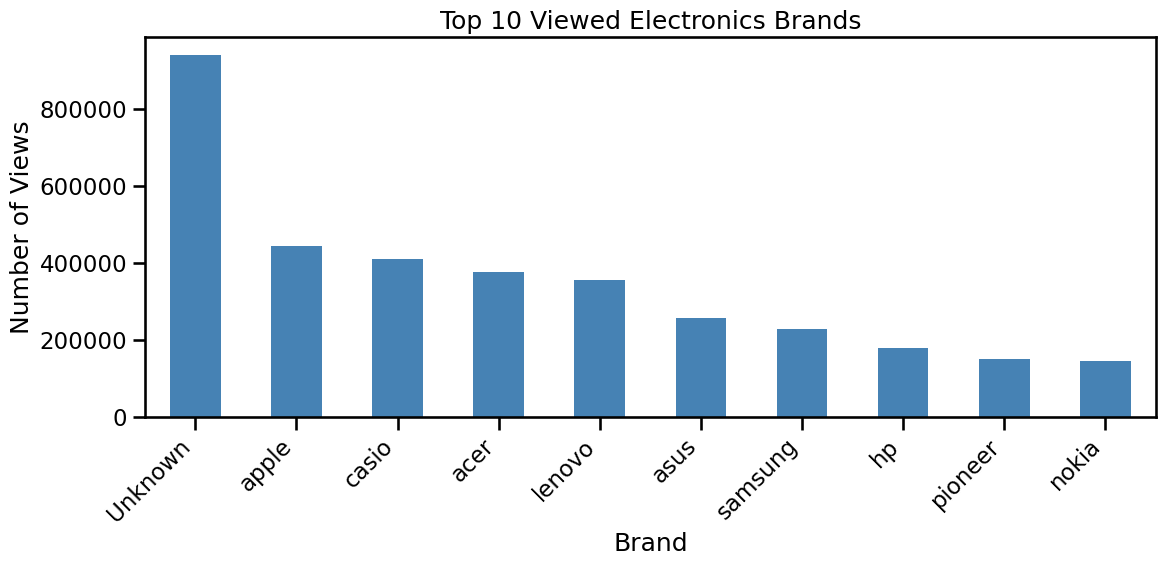

C:\Users\PC\AppData\Local\Temp\ipykernel_8336\3597134705.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=electronics_df, x='event_type', palette='pastel')


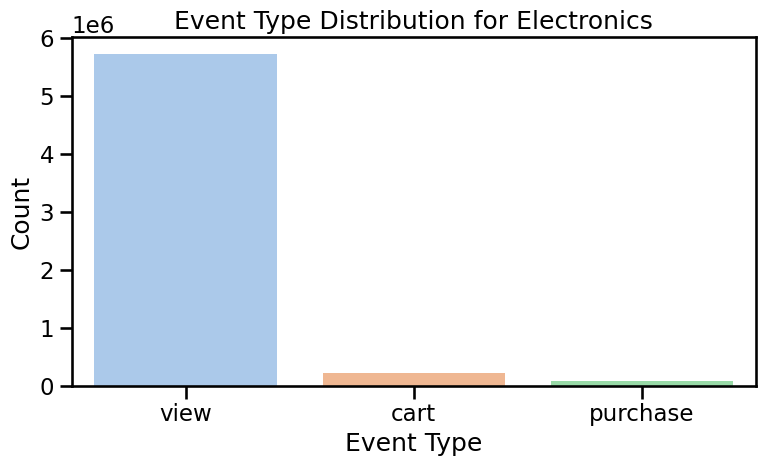

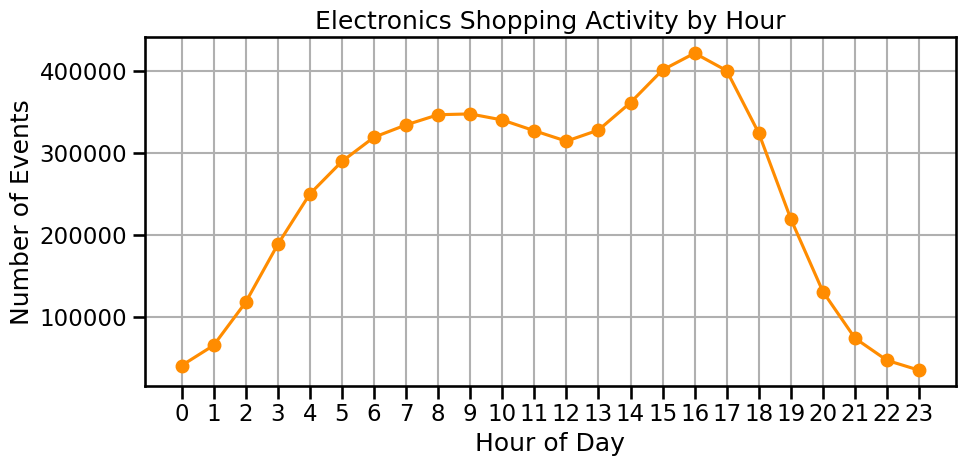

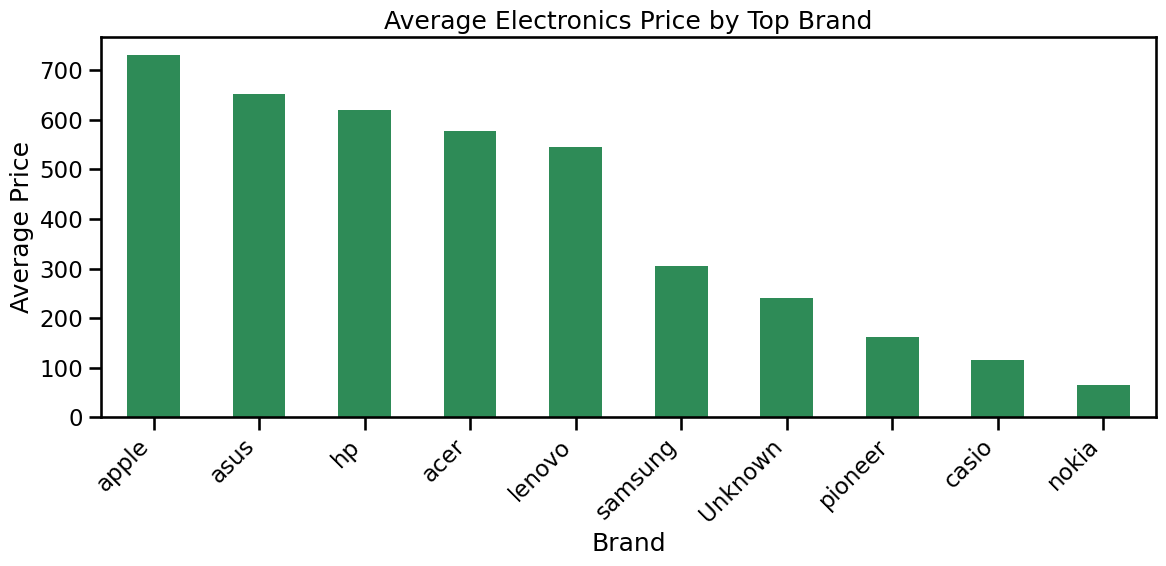

In [14]:
# Bar chart for the top viewed brands
plt.figure(figsize=(12, 6))
view_counts.plot(kind='bar', color='steelblue')
plt.title('Top 10 Viewed Electronics Brands')
plt.xlabel('Brand')
plt.ylabel('Number of Views')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Count plot for event type distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=electronics_df, x='event_type', palette='pastel')
plt.title('Event Type Distribution for Electronics')
plt.xlabel('Event Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Line plot for shopping activity by hour
plt.figure(figsize=(10, 5))
hourly_activity.plot(kind='line', marker='o', color='darkorange')
plt.title('Electronics Shopping Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Events')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# Bar chart for average price by brand
plt.figure(figsize=(12, 6))
average_price_by_brand.plot(kind='bar', color='seagreen')
plt.title('Average Electronics Price by Top Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The visualizations show which brands attract the most views, how event types are distributed, the hours when electronics activity peaks, and how average price varies across leading brands.

## Business Insights

Based on the analysis, several patterns emerge that can inform business strategy for electronics ecommerce.

- Customer browsing behavior is concentrated in specific electronics brands, suggesting that merchandising and search optimization should target the most viewed items.
- Peak shopping activity appears during certain hours, which indicates that promotions and customer support should align with these high-engagement windows.
- A large share of events are views and carts rather than purchases, highlighting the presence of cart abandonment and the need for better checkout incentives or follow-up.
- The price range analysis shows distinct customer interest in different budget segments. Low and mid-price electronics likely generate consistent engagement, while premium items may need additional trust signals or financing options.
- Brands with high average prices may have lower conversion unless supported by strong product detail pages and reviews, so pricing strategy should consider both demand and purchase likelihood.

## Final Recommendations

The following recommendations are based on the electronics behavior patterns observed in this dataset.

1. Prioritize retargeting campaigns for visitors who view electronics products but do not complete purchases, with special offers for top-viewed brands.
2. Schedule promotional emails and offers during peak activity hours identified in the hourly analysis to increase conversion at the times customers are most active.
3. Simplify the checkout process for electronics and provide clearer shipping, warranty, and return information to reduce cart abandonment.
4. Invest in product page quality for premium electronics, including images, reviews, and financing options, to support higher average price brand conversions.
5. Use price range segmentation to design category-specific bundles and promotions for the 0-100 and 100-500 segments, which are likely to attract larger volumes of shoppers.

## Export Clean Dataset

Save the cleaned electronics dataset for later modeling or reporting.

## Work Summary - Electronics Ecommerce Analysis Project

### Project Overview
This comprehensive analysis examined a large electronics ecommerce dataset (6.09 million records) to understand customer behavior, identify cart abandonment patterns, and uncover opportunities for improving conversion rates across product segments.

### Data Processing & Cleaning
1. **Dataset Loading**: Imported 6.09M records with 9 columns (event_time, event_type, product_id, category_id, category_code, brand, price, user_id, user_session)
2. **Data Quality Assessment**: 
   - Identified only 1 missing value in user_session column
   - No missing data in brand or category_code fields
   - Removed 67,696 duplicate records (1.1% of dataset)
3. **Data Type Conversion**: Converted event_time to datetime format for temporal analysis
4. **Feature Engineering**:
   - Extracted time-based features: hour, day_name, month from event timestamps
   - Created price range segmentation: 0-100, 100-500, 500-1000, 1000+ categories
   - Final cleaned dataset: 6,025,596 records

### Key Business Findings

#### 1. **Critical Issue: Cart Abandonment**
- Total Views: 5.72M (94.9% of events)
- Cart Additions: 222K (3.7% of events)
- Purchases: 83K (1.4% of events)
- **Conversion Rate: Only 1.5% from view to purchase** ← **Major opportunity for improvement**

#### 2. **Brand Performance Analysis**
- **Top Viewed Brands**: Unknown (938K), Apple (445K), Casio (410K), Acer (376K), Lenovo (356K)
- **Top Purchased Brands**: Apple (16.7K), Acer (9.3K), Unknown (7.9K), Lenovo (5.7K), Casio (4.8K)
- **Price Analysis**: 
  - Premium brands: Apple ($730 avg), ASUS ($652), HP ($619)
  - Budget brands: Nokia ($64), Casio ($116), Pioneer ($161)

#### 3. **Hourly Shopping Patterns**
- **Peak Activity**: 3-5 PM (15-17:00) with 400K+ events each hour
- **Morning Rush**: 5-9 AM with high activity (289K-346K events)
- **Low Activity**: Midnight-4 AM (34K-188K events)
- **Recommendation**: Schedule promotions, customer support, and retargeting during peak hours

#### 4. **Product Category Distribution**
1. Electronics Clocks: 2.16M events (35.8% of traffic)
2. Audio Headphones: 1.50M events (24.9%)
3. Video/TV: 427K events (7.1%)
4. Audio Subwoofers: 369K events (6.1%)
5. Camera/Video: 288K events (4.8%)

#### 5. **Price Segmentation Analysis**
- **$100-500 Range**: 2.66M events (44.1%) - Largest segment
- **$0-100 Range**: 2.11M events (35.0%)
- **$500-1000 Range**: 813K events (13.5%)
- **$1000+ Premium**: 445K events (7.4%)

### Visualizations Generated
1. **Top 10 Viewed Brands Chart**: Bar plot showing brand popularity by views
2. **Event Type Distribution**: Pie/count chart showing the breakdown of view/cart/purchase events
3. **Hourly Activity Trend**: Line chart showing shopping activity peaks throughout the day
4. **Average Price by Brand**: Bar chart showing price positioning across leading brands

### Outputs Delivered
✅ Cleaned and deduplicated dataset (6.02M records)
✅ Time-based features (hour, day, month)
✅ Price range segmentation
✅ 4 professional visualizations
✅ Comprehensive statistical summaries
✅ Exported clean dataset as `cleaned_electronics_data.csv`

### Strategic Recommendations
1. **Conversion Optimization**: Implement targeted retargeting campaigns for cart abandoners with personalized offers during peak hours (3-5 PM)
2. **Checkout Improvement**: Simplify checkout process and provide shipping/warranty/return information for electronics
3. **Premium Product Strategy**: Add financing options, trust signals, and detailed reviews for premium electronics ($500+)
4. **Price-Based Marketing**: Design category-specific bundles and promotions for 0-100 and 100-500 segments (79% of traffic)
5. **Brand Focus**: Prioritize merchandising and search optimization for high-view brands (Apple, Casio, Acer) to maximize conversion
6. **Hourly Optimization**: Align customer support, live chat, and promotional notifications with identified peak activity windows

### Technical Stack
- **Libraries Used**: Pandas, NumPy, Matplotlib, Seaborn
- **Data Processing**: Filtering, grouping, aggregation, time series analysis
- **Visualization**: Multi-format charts (bar, line, count plots)
- **Output Format**: CSV export for further modeling and reporting

In [15]:
electronics_df.to_csv('cleaned_electronics_data.csv', index=False)
print('Cleaned electronics dataset saved as cleaned_electronics_data.csv')

Cleaned electronics dataset saved as cleaned_electronics_data.csv
